# 06 — Conditional Flow Matching from scratch

Train a continuous normalizing flow with **Lipman 2023's conditional flow matching** on the same 4-mode 2D Gaussian mixture from notebook 02. Compare quality to the RealNVP.

Key differences from RealNVP:
- No coupling layers / Jacobian gymnastics.
- Train objective is **plain MSE** of `v_\theta((1-t)z_0 + t x_1, t)` against `x_1 - z_0`.
- Inference = integrate the learned ODE (Euler here).
- Densities require integrating `\nabla \cdot v` — not computed in this notebook; we judge by sample quality.


In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
from tqdm.auto import trange
from boltzmann_generators.flows import CNFModel, VelocityField

torch.manual_seed(0); np.random.seed(0)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

mps


/Users/manumartinm/Documents/proyectos/boltzmann_generators/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Same 4-mode Gaussian mixture as notebook 02

In [2]:
MODES = torch.tensor([[ 2.,  2.], [-2., 2.], [-2., -2.], [ 2., -2.]])
SIGMA = 0.35
def sample_target(n):
    idx = torch.multinomial(torch.ones(4)/4, n, replacement=True)
    return MODES[idx] + SIGMA * torch.randn(n, 2)
x_train = sample_target(20_000)
print(f'train: {x_train.shape}')

train: torch.Size([20000, 2])


## 2. Build & train CNF with CFM loss

#params: 52,354



CFM:   0%|          | 0/5000 [00:00<?, ?it/s]


CFM:   0%|          | 1/5000 [00:01<2:17:32,  1.65s/it]


CFM:   1%|          | 37/5000 [00:01<02:50, 29.19it/s] 


CFM:   2%|▏         | 81/5000 [00:01<01:09, 71.03it/s]

...


CFM:  97%|█████████▋| 4853/5000 [00:14<00:00, 359.48it/s]


CFM:  98%|█████████▊| 4893/5000 [00:14<00:00, 370.34it/s]


CFM:  99%|█████████▊| 4935/5000 [00:14<00:00, 382.89it/s]


CFM: 100%|█████████▉| 4979/5000 [00:14<00:00, 398.38it/s]


CFM: 100%|██████████| 5000/5000 [00:14<00:00, 339.11it/s]

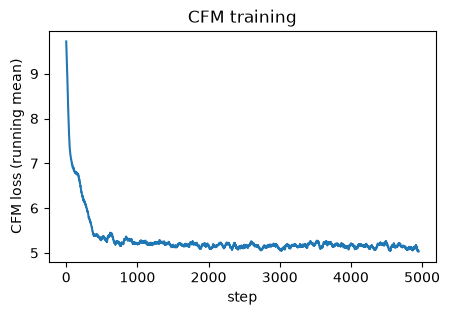

final CFM loss: 5.0618


In [3]:
v = VelocityField(dim=2, hidden_dim=128, num_hidden=4, num_freqs=8)
model = CNFModel(v).to(device)
print(f'#params: {sum(p.numel() for p in model.parameters()):,}')

x_dev = x_train.to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
hist = []
for step in trange(5000, desc='CFM'):
    idx = torch.randint(0, x_dev.shape[0], (512,), device=device)
    loss = model.cfm_loss(x_dev[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())

plt.figure(figsize=(5, 3))
# Running mean for clarity
import numpy as np
h = np.array(hist); win = 50
running = np.convolve(h, np.ones(win)/win, mode='valid')
plt.plot(running); plt.xlabel('step'); plt.ylabel('CFM loss (running mean)'); plt.title('CFM training')
plt.show()
print(f'final CFM loss: {hist[-1]:.4f}')

## 3. Sample (integrate ODE with Euler) and compare with RealNVP

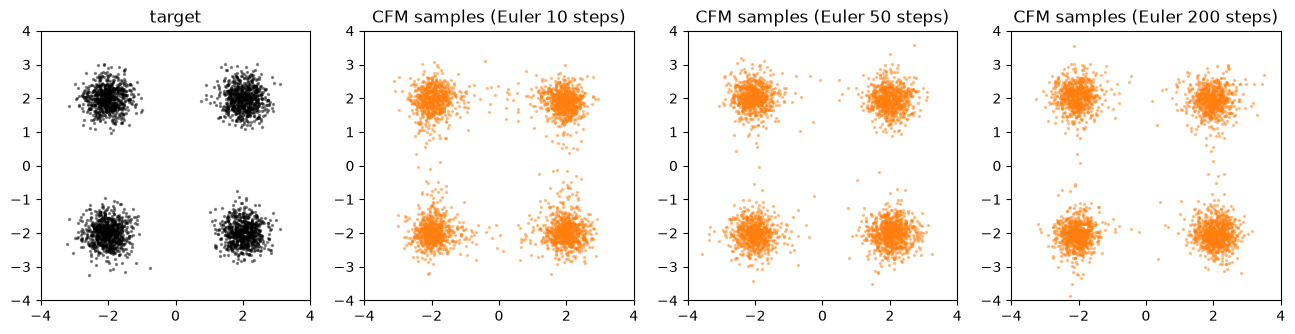

In [4]:
# Test several integrator step counts
configs = [10, 50, 200]
fig, axes = plt.subplots(1, len(configs) + 1, figsize=(4 * (len(configs) + 1), 4))
axes[0].scatter(x_train[:3000, 0], x_train[:3000, 1], s=2, alpha=0.4, color='black')
axes[0].set_title('target'); axes[0].set_aspect('equal'); axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
for ax, n_steps in zip(axes[1:], configs):
    with torch.no_grad():
        x = model.sample(3000, device=device, n_steps=n_steps).cpu()
    ax.scatter(x[:, 0], x[:, 1], s=2, alpha=0.4, color='C1')
    ax.set_title(f'CFM samples (Euler {n_steps} steps)')
    ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.show()

## 4. Trajectories — show the flow at work

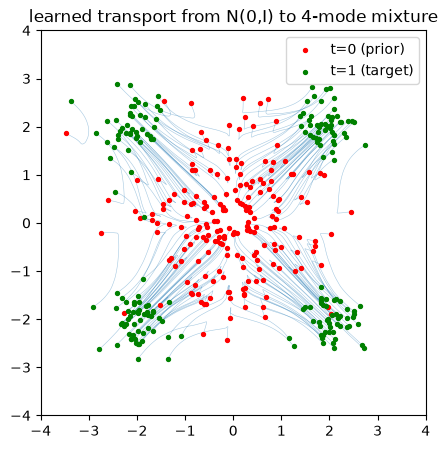

In [5]:
# Trace a small batch of trajectories
with torch.no_grad():
    n_traj, n_steps = 200, 100
    x = torch.randn(n_traj, 2, device=device)
    dt = 1.0 / n_steps
    traj = [x.cpu().clone()]
    for k in range(n_steps):
        t = torch.full((n_traj,), k * dt, device=device)
        x = x + dt * model.v(x, t)
        traj.append(x.cpu().clone())
traj = torch.stack(traj)  # (T, n, 2)

fig, ax = plt.subplots(figsize=(5, 5))
for i in range(n_traj):
    ax.plot(traj[:, i, 0], traj[:, i, 1], lw=0.4, alpha=0.4, color='C0')
ax.scatter(traj[0, :, 0], traj[0, :, 1], s=8, color='red', label='t=0 (prior)', zorder=3)
ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=8, color='green', label='t=1 (target)', zorder=3)
ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.legend()
ax.set_title('learned transport from N(0,I) to 4-mode mixture')
plt.show()

## 5. Verification

Expected:
- CFM loss decreases steadily to a low plateau (~0.5–1.5 for this target).
- Samples with 200 Euler steps cover all 4 modes with shape similar to RealNVP from notebook 02.
- Samples with 10 steps are visibly worse (transport not fully completed) → number-of-function-evaluations vs quality trade-off.
- Trajectories show streamlines from the origin Gaussian to the 4 corners.

What we did NOT do (intentionally minimal):
- **Exact log-density** of CFM samples — requires integrating `\nabla \cdot v_\theta` (Hutchinson trace) along the trajectory. Not needed for CFM training, but needed for BG-style reweighting.
- **Adjoint/torchdiffeq** — for higher-dim or tighter accuracy use `torchdiffeq.odeint` with adaptive RK; our Euler is enough for this 2D demo.
- **BG via CFM** — combining CFM pretrain with KL_z fine-tuning (need density). Klein & Noé 2024 do this via a hybrid scheme; see `theory/05_transferable_bg.md`.

Next: M10 (optional, dipeptide). The transferable BG extension lives in scope but requires either MD trajectories or a synthetic Ramachandran-like potential. We'll do the latter to keep deps light.